<a href="https://colab.research.google.com/github/jdnogues/DIO/blob/main/Desafio_DIO_Sistema_de_Recomenda%C3%A7%C3%A3o_por_Imagens_Digitais.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Projeto: Sistema de Recomendação por Similaridade de Imagens (4 Produtos)**

**Objetivo:** Construir um sistema que recebe uma imagem de um produto, a classifica em uma de quatro categorias,

**Passo 1:** Escolha dos Produtos e Criação do Dataset
Primeiro, precisamos escolher 4 classes de produtos e montar um pequeno dataset para cada uma. Para um bom desempenho, é ideal que as classes sejam visualmente distintas.

Classes Escolhidas:

**sneakers (tênis)**;
**watches (relógios)**;
**backpacks (mochilas)**;
**laptops**;

Agora, vamos criar um pequeno dataset baixando imagens da internet para cada classe. Usaremos uma biblioteca simples para isso.

**Passo 1.1 Instalação das Bibliotecas**

Vamos primeiro instalar os pacotes.

In [1]:
# Instala um conjunto completo, específico e estável de bibliotecas.
print("Instalando um ambiente de bibliotecas controlado e compatível...")

# Bibliotecas para download de dados e busca por similaridade
!pip install -q ddgs tqdm annoy

# Instala versões específicas e compatíveis do TensorFlow e Hub
!pip install -q tensorflow==2.12.0 tensorflow-hub==0.14.0

print("\nAmbiente controlado instalado com sucesso! Por favor, reinicie o ambiente de execução.")

Instalando um ambiente de bibliotecas controlado e compatível...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 647.5/647.5 kB 25.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 80.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 586.0/586.0 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.3/90.3 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 94.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━

# **IMPORTANTE: Reinicie o Ambiente de Execução Agora**

Após a Célula 1.1 terminar, vá ao menu Ambiente de execução > Reiniciar sessão (ou Runtime > Restart session). Uma janela de confirmação aparecerá, clique em "Sim".

**Este passo é obrigatório** para que o Colab carregue as bibliotecas que acabamos de instalar.

**Passo 1.2: Criação do Dataset**

Execute esta célula somente após ter reiniciado o ambiente de execução.

In [1]:
from ddgs import DDGS
from pathlib import Path
import os
import requests
from tqdm import tqdm

def search_images(term, max_images=50):
    """Retorna URLs de imagens para um termo de busca."""
    print(f"Buscando por '{term}'...")

    results = DDGS().images(
        query=term,
        max_results=max_images
    )
    return [r['image'] for r in results]

def download_images_manual(dest_folder, urls):
    """
    Função para baixar imagens de uma lista de URLs para uma pasta de destino.
    """
    os.makedirs(dest_folder, exist_ok=True)
    for i, url in enumerate(tqdm(urls, desc=f"Baixando em {dest_folder.name}")):
        try:
            response = requests.get(url, timeout=10)
            response.raise_for_status()

            content_type = response.headers.get('content-type')
            if content_type and 'image' in content_type:
                extension = content_type.split('/')[-1].split(';')[0]
                filename = f"{i+1:04d}.{extension}"
                filepath = os.path.join(dest_folder, filename)

                with open(filepath, 'wb') as f:
                    f.write(response.content)
            else:
                print(f"Conteúdo não é uma imagem: {url}")

        except Exception as e:
            print(f"Falha ao baixar {url}: {e}")

# --- Criação do Dataset ---
product_classes = "sneakers", "watches", "backpacks", "laptops"
dataset_path = Path("dataset")

# Baixa as imagens para cada classe
for cls in product_classes:
    dest = dataset_path / cls
    urls = search_images(f'{cls} photo')
    download_images_manual(dest, urls)

print("\nDataset com 4 classes criado com sucesso na pasta 'dataset/'!")

Buscando por 'sneakers photo'...


Baixando em sneakers:  26%|██▌       | 13/50 [00:01<00:02, 13.74it/s]

Conteúdo não é uma imagem: http://images.summitmedia-digital.com/spotph/images/2023/01/27/guide-to-adidas-sneakers--history-popular-styles-1200-1674808953.jpg


Baixando em sneakers:  42%|████▏     | 21/50 [00:12<00:46,  1.60s/it]

Falha ao baixar https://cdn-images.farfetch-contents.com/19/55/44/25/19554425_43605663_1000.jpg: HTTPSConnectionPool(host='cdn-images.farfetch-contents.com', port=443): Read timed out. (read timeout=10)


...

Falha ao baixar https://pcinternational.co.za/wp-content/uploads/2022/09/4a425a40-fd56-11ec-beee-be16b8848f18.cf_.jpg: 404 Client Error: Not Found for url: https://pcinternational.co.za/wp-content/uploads/2022/09/4a425a40-fd56-11ec-beee-be16b8848f18.cf_.jpg


Baixando em laptops:  88%|████████▊ | 44/50 [00:05<00:00, 13.56it/s]

Falha ao baixar https://www.bhphotovideo.com/images/images2500x2500/asus_d550ca_bh01_15_6_notebook_computer_1009860.jpg: 403 Client Error: Forbidden for url: https://www.bhphotovideo.com/images/images2500x2500/asus_d550ca_bh01_15_6_notebook_computer_1009860.jpg


Baixando em laptops: 100%|██████████| 50/50 [00:05<00:00,  8.72it/s]

Falha ao baixar https://pisces.bbystatic.com/image2/BestBuy_US/images/products/6529/6529399_sd.jpg: 403 Client Error: Forbidden for url: https://pisces.bbystatic.com/image2/BestBuy_US/images/products/6529/6529399_sd.jpg

Dataset com 4 classes criado com sucesso na pasta 'dataset/'!


**Passo 2: Fine-Tuning do Modelo Encoder (Classificador)**

*(Adaptado do notebook original)*

Agora, vamos treinar (fine-tune) um modelo de classificação para aprender a diferenciar nossas 4 classes de produtos. Usaremos o mesmo modelo BiT da base, que é excelente. Ao final, teremos dois artefatos importantes:

**1.O Classificador Completo:** Para nos dizer qual é o objeto.

**2.O Extrator de Características:** Para gerar o vetor de similaridade.

In [2]:
import tensorflow as tf
import tensorflow_hub as hub
from pathlib import Path

# Configurações e Carregamento de Dados (sem alterações)
MODULE_HANDLE = 'https://tfhub.dev/google/bit/m-r50x3/1'
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
product_classes = sorted([p.name for p in Path("dataset").iterdir() if p.is_dir()])
NUM_CLASSES = len(product_classes)

data_dir = Path("dataset")
datagen_kwargs = dict(rescale=1./255, validation_split=.20)
dataflow_kwargs = dict(target_size=IMAGE_SIZE, batch_size=BATCH_SIZE, interpolation="bilinear")

train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(**datagen_kwargs)
train_generator = train_datagen.flow_from_directory(
    data_dir, subset="training", shuffle=True, **dataflow_kwargs)

valid_datagen = tf.keras.preprocessing.image.ImageDataGenerator(**datagen_kwargs)
valid_generator = valid_datagen.flow_from_directory(
    data_dir, subset="validation", shuffle=False, **dataflow_kwargs)

# Construção e Treinamento do Modelo (sem alterações)
print("Construindo e treinando o classificador...")
inputs = tf.keras.Input(shape=IMAGE_SIZE + (3,))
x = hub.KerasLayer(MODULE_HANDLE, trainable=False)(inputs)
x = tf.keras.layers.Dense(128, activation='relu')(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')(x)
model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=['accuracy'])

model.fit(
    train_generator,
    epochs=5,
    steps_per_epoch=(train_generator.samples // BATCH_SIZE),
    validation_data=valid_generator,
    validation_steps=(valid_generator.samples // BATCH_SIZE))

# --- Salvando apenas o classificador ---
print("\nSalvando o classificador...")
model.save('product_classifier')
print("\nPasso 2 concluído com sucesso!")

Found 136 images belonging to 4 classes.
Found 33 images belonging to 4 classes.
Construindo e treinando o classificador...
Epoch 1/5


/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


4/4 [==============================] - 346s 88s/step - loss: 7.5071 - accuracy: 0.4375 - val_loss: 3.8368 - val_accuracy: 0.7188
Epoch 2/5
4/4 [==============================] - 281s 74s/step - loss: 1.7800 - accuracy: 0.7981 - val_loss: 0.3276 - val_accuracy: 0.8750
Epoch 3/5
4/4 [==============================] - 256s 66s/step - loss: 0.3404 - accuracy: 0.8558 - val_loss: 0.1866 - val_accuracy: 0.9375
Epoch 4/5
4/4 [==============================] - 263s 82s/step - loss: 0.0617 - accuracy: 0.9808 - val_loss: 0.0669 - val_accuracy: 0.9688
Epoch 5/5
4/4 [==============================] - 278s 72s/step - loss: 0.0047 - accuracy: 1.0000 - val_loss: 0.0364 - val_accuracy: 0.9688

Salvando o classificador...



Passo 2 concluído com sucesso!


**Passo 3: Vetorização e Indexação do Dataset**

*(Adaptado do notebook original)*

Agora, usamos nosso extrator de características recém-treinado para converter todas as imagens do nosso dataset em vetores numéricos e, em seguida, os indexamos com o Annoy para uma busca rápida.

In [3]:
from pathlib import Path
import numpy as np
from tqdm import tqdm
import tensorflow as tf
import tensorflow_hub as hub
from annoy import AnnoyIndex
import pickle

print("Carregando o modelo de extração de características (MobileNet)...")
FEATURE_EXTRACTOR_HANDLE = "https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4"
feature_extractor_model = hub.KerasLayer(FEATURE_EXTRACTOR_HANDLE,
                                       input_shape=(224, 224, 3),
                                       trainable=False)
dims = 1280

dataset_path = Path("dataset")
product_classes = sorted([p.name for p in dataset_path.iterdir() if p.is_dir()])
image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.gif']

# --- Loop principal para criar um índice para cada classe ---
for cls in product_classes:
    print("\n" + "="*50)
    print(f"Processando a classe: {cls.upper()}")
    print("="*50)

    class_path = dataset_path / cls
    img_paths = [p for ext in image_extensions for p in class_path.rglob(ext)]

    imgvec_path = Path(f"image_vectors/{cls}")
    imgvec_path.mkdir(exist_ok=True, parents=True)

    print(f"Gerando {len(img_paths)} vetores de características...")
    for filename in tqdm(img_paths):
        img = tf.io.read_file(str(filename))
        img = tf.io.decode_image(img, channels=3)
        img = tf.image.resize(img, [224, 224]) / 255.0
        img = img[tf.newaxis, ...]

        features = feature_extractor_model(img)
        feature_set = np.squeeze(features)

        outfile_name = filename.stem + ".npz"
        out_path_file = imgvec_path / outfile_name
        np.savetxt(out_path_file, feature_set, delimiter=',')

    print(f"\nConstruindo o índice de similaridade para '{cls}'...")
    file_index_to_path = {i: path for i, path in enumerate(img_paths)}

    annoy_index = AnnoyIndex(dims, metric='angular')

    for i, f_path in tqdm(file_index_to_path.items()):
        vector_path = imgvec_path / (f_path.stem + ".npz")
        v = np.loadtxt(vector_path)
        annoy_index.add_item(i, v)

    annoy_index.build(10)
    # Salva o índice com o nome da classe (ex: sneakers.ann)
    annoy_index.save(f'{cls}_index.ann')

    # Salva o mapeamento com o nome da classe (ex: sneakers_map.pkl)
    with open(f'{cls}_map.pkl', 'wb') as f:
        pickle.dump(file_index_to_path, f)

print("\n✅ Índices de similaridade por classe criados com sucesso!")

Carregando o modelo de extração de características (MobileNet)...

Processando a classe: BACKPACKS
Gerando 40 vetores de características...


100%|██████████| 40/40 [00:03<00:00, 11.62it/s]



Construindo o índice de similaridade para 'backpacks'...


100%|██████████| 40/40 [00:00<00:00, 1062.50it/s]



Processando a classe: LAPTOPS
Gerando 45 vetores de características...


...


Processando a classe: WATCHES
Gerando 44 vetores de características...


100%|██████████| 44/44 [00:04<00:00,  9.05it/s]



Construindo o índice de similaridade para 'watches'...


100%|██████████| 44/44 [00:00<00:00, 1065.69it/s]


✅ Índices de similaridade por classe criados com sucesso!


**Passo 4: Construindo o Sistema de Recomendação**

Esta é a parte central, onde juntamos tudo. Criaremos uma função que recebe uma imagem, a classifica, encontra similares e busca novas na web.

**Célula 4.1: Carregando os Modelos e Índices (Execute uma vez)**

Primeiro, vamos carregar todos os nossos artefatos (modelos, índice, mapeamentos) para a memória. Isso é feito apenas uma vez no início.

In [4]:
import tensorflow as tf
from pathlib import Path

print("Carregando o classificador para a memória...")
classifier = tf.keras.models.load_model('product_classifier')
class_names = sorted([p.name for p in Path("dataset").iterdir() if p.is_dir()])
print("✅ Ambiente de recomendação pronto!")

Carregando o classificador para a memória...
✅ Ambiente de recomendação pronto!


**Célula 4.2: Definindo o Sistema de Recomendação**

Agora, definimos nossas funções. Elas irão usar os modelos que já estão carregados na memória, tornando a execução muito mais rápida.

In [7]:
import numpy as np
from ddgs import DDGS
from annoy import AnnoyIndex
import pickle
import tensorflow_hub as hub

# Carrega o modelo de similaridade direto do Hub para gerar o vetor da imagem de entrada
FEATURE_EXTRACTOR_HANDLE = "https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4"
feature_extractor_model = hub.KerasLayer(FEATURE_EXTRACTOR_HANDLE, input_shape=(224, 224, 3), trainable=False)
dims = 1280

def search_images_online(term, max_images=5):
    """Função para buscar novas imagens na web."""
    print(f"Buscando por '{term}' na web...")
    with DDGS() as ddgs:
        results = ddgs.images(query=term, max_results=max_images)
        return [r['image'] for r in results]

def get_recommendations_complete(image_path, top_k=5):
    """
    Classifica a imagem, busca por similares no índice da classe prevista
    e também busca por novas imagens na web.
    """
    img = tf.io.read_file(image_path)
    img = tf.io.decode_image(img, channels=3)
    img_preprocessed = tf.image.resize(img, [224, 224]) / 255.0
    img_preprocessed = img_preprocessed[tf.newaxis, ...]

    # --- 1. Classificação ---
    print("Classificando o objeto...")
    predictions = classifier.predict(img_preprocessed, verbose=0)
    predicted_class_index = np.argmax(predictions)
    predicted_class_name = class_names[predicted_class_index]

    # --- 2. Busca por Similaridade Direcionada ---
    print(f"Buscando por imagens similares dentro da classe '{predicted_class_name}'...")
    similar_images_paths = []
    try:
        annoy_index = AnnoyIndex(dims, 'angular')
        annoy_index.load(f'{predicted_class_name}_index.ann')

        with open(f'{predicted_class_name}_map.pkl', 'rb') as f:
            file_map = pickle.load(f)

        input_vector = feature_extractor_model(img_preprocessed)
        input_vector = np.squeeze(input_vector)

        similar_indices = annoy_index.get_nns_by_vector(input_vector, n=top_k, include_distances=False)
        similar_images_paths = [file_map[i] for i in similar_indices]

    except FileNotFoundError:
        print(f"Erro: Arquivo de índice para a classe '{predicted_class_name}' não encontrado.")

    # --- 3. Busca por Novas Imagens (na web) ---
    # ADICIONADO DE VOLTA: Chamada para a função de busca online
    new_online_images_urls = search_images_online(f'buy {predicted_class_name}')

    return predicted_class_name, similar_images_paths, new_online_images_urls

**Célula 4.3: Teste Interativo**

Finalmente, esta célula permite que você faça o upload de uma imagem e veja o sistema completo em ação.

Faça o upload de uma imagem de teste (sneaker, watch, backpack ou laptop):


Saving mochila.jpg to mochila (1).jpg

Imagem enviada:


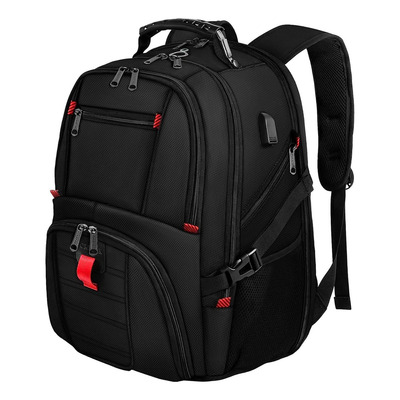

Classificando o objeto...
Buscando por imagens similares dentro da classe 'backpacks'...
Buscando por 'buy backpacks' na web...

✅ Objeto classificado como: BACKPACKS

➡️ Imagens similares encontradas na nossa base de dados (da mesma classe):


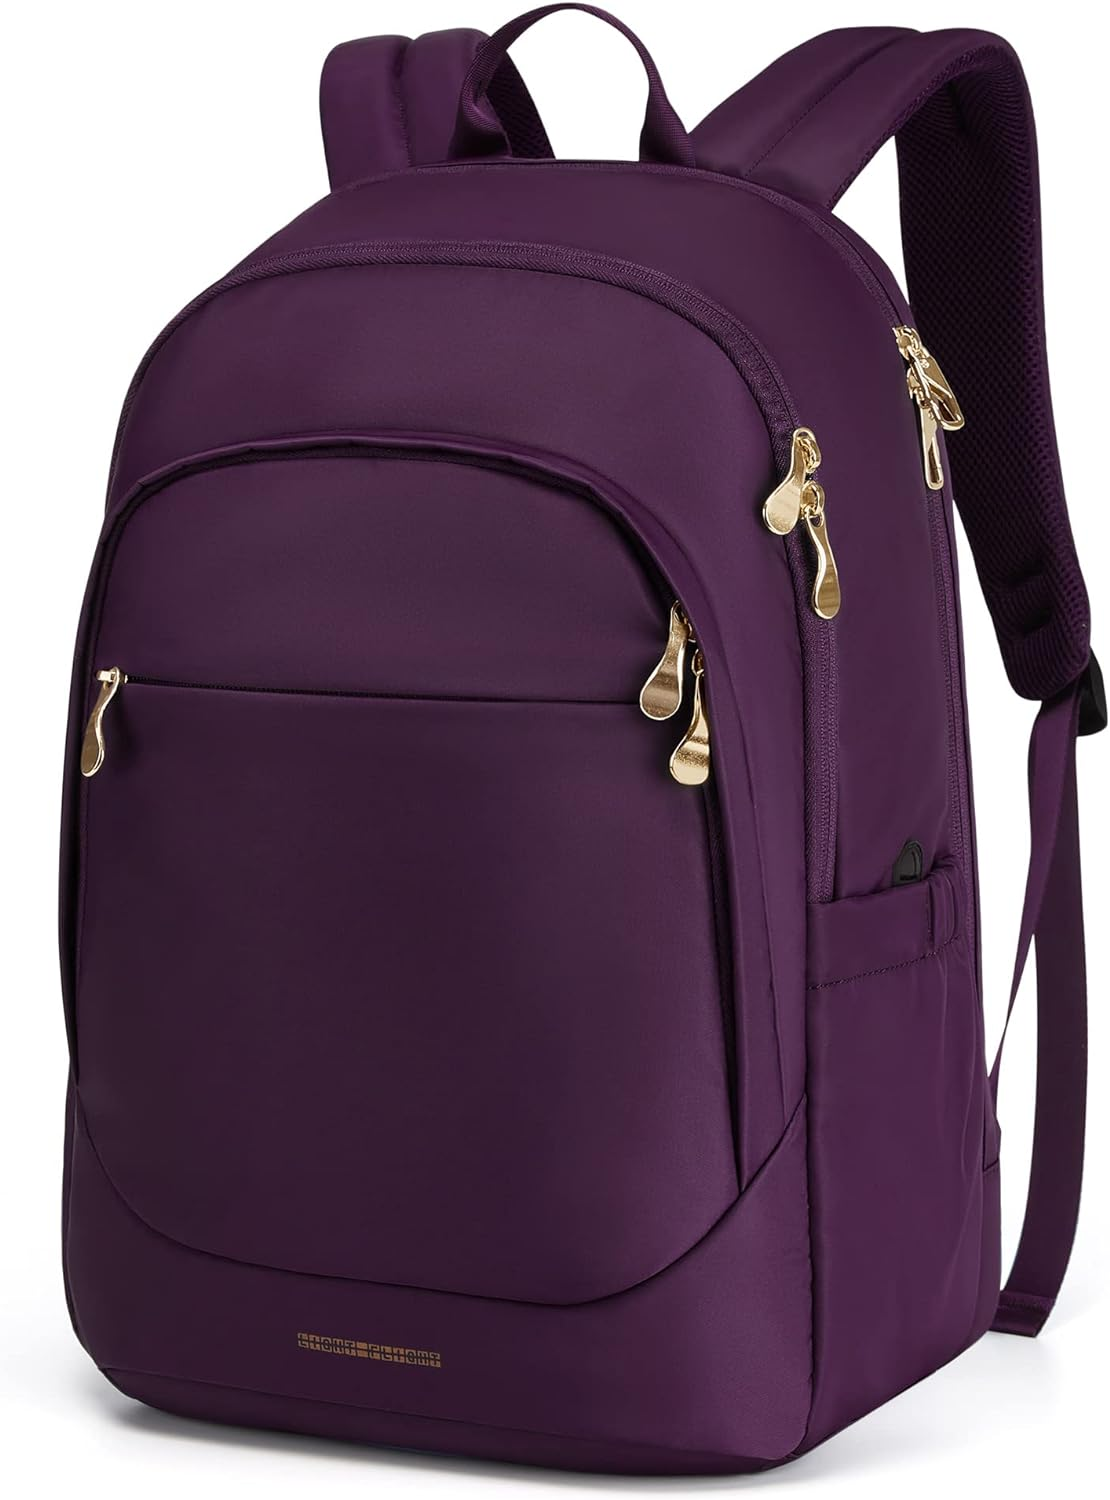

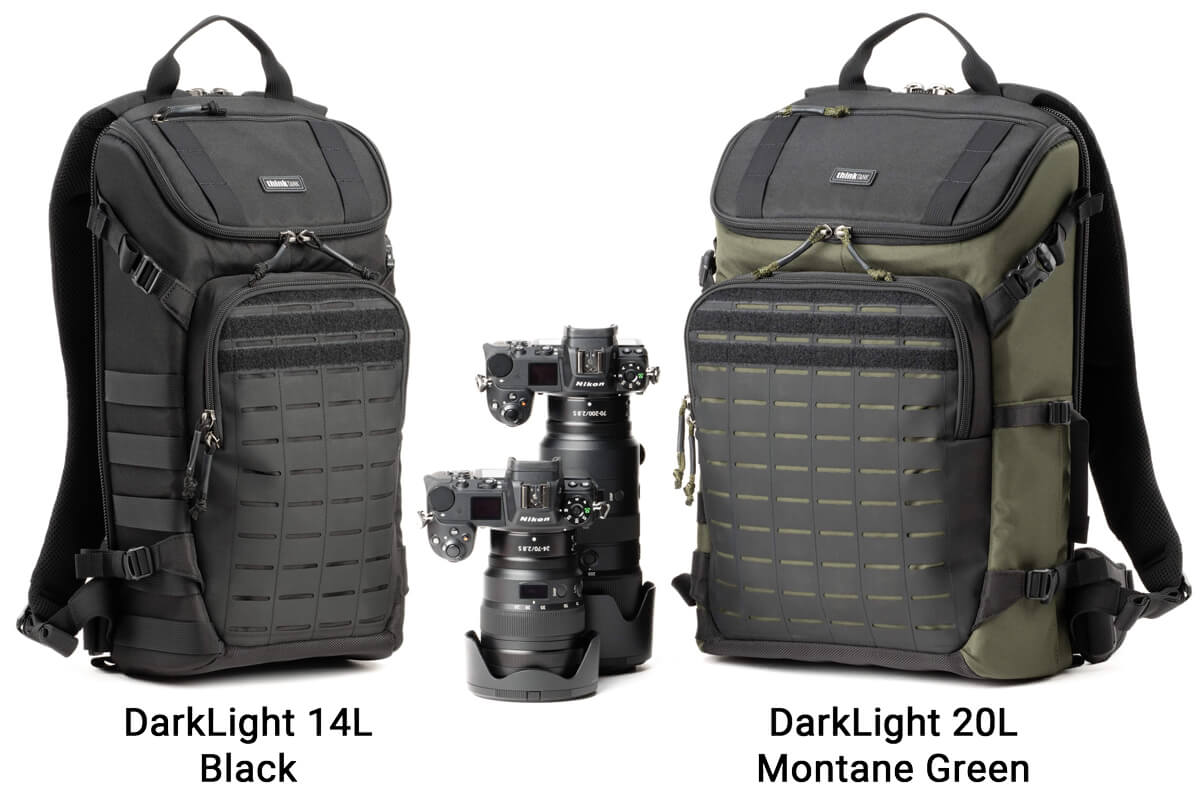

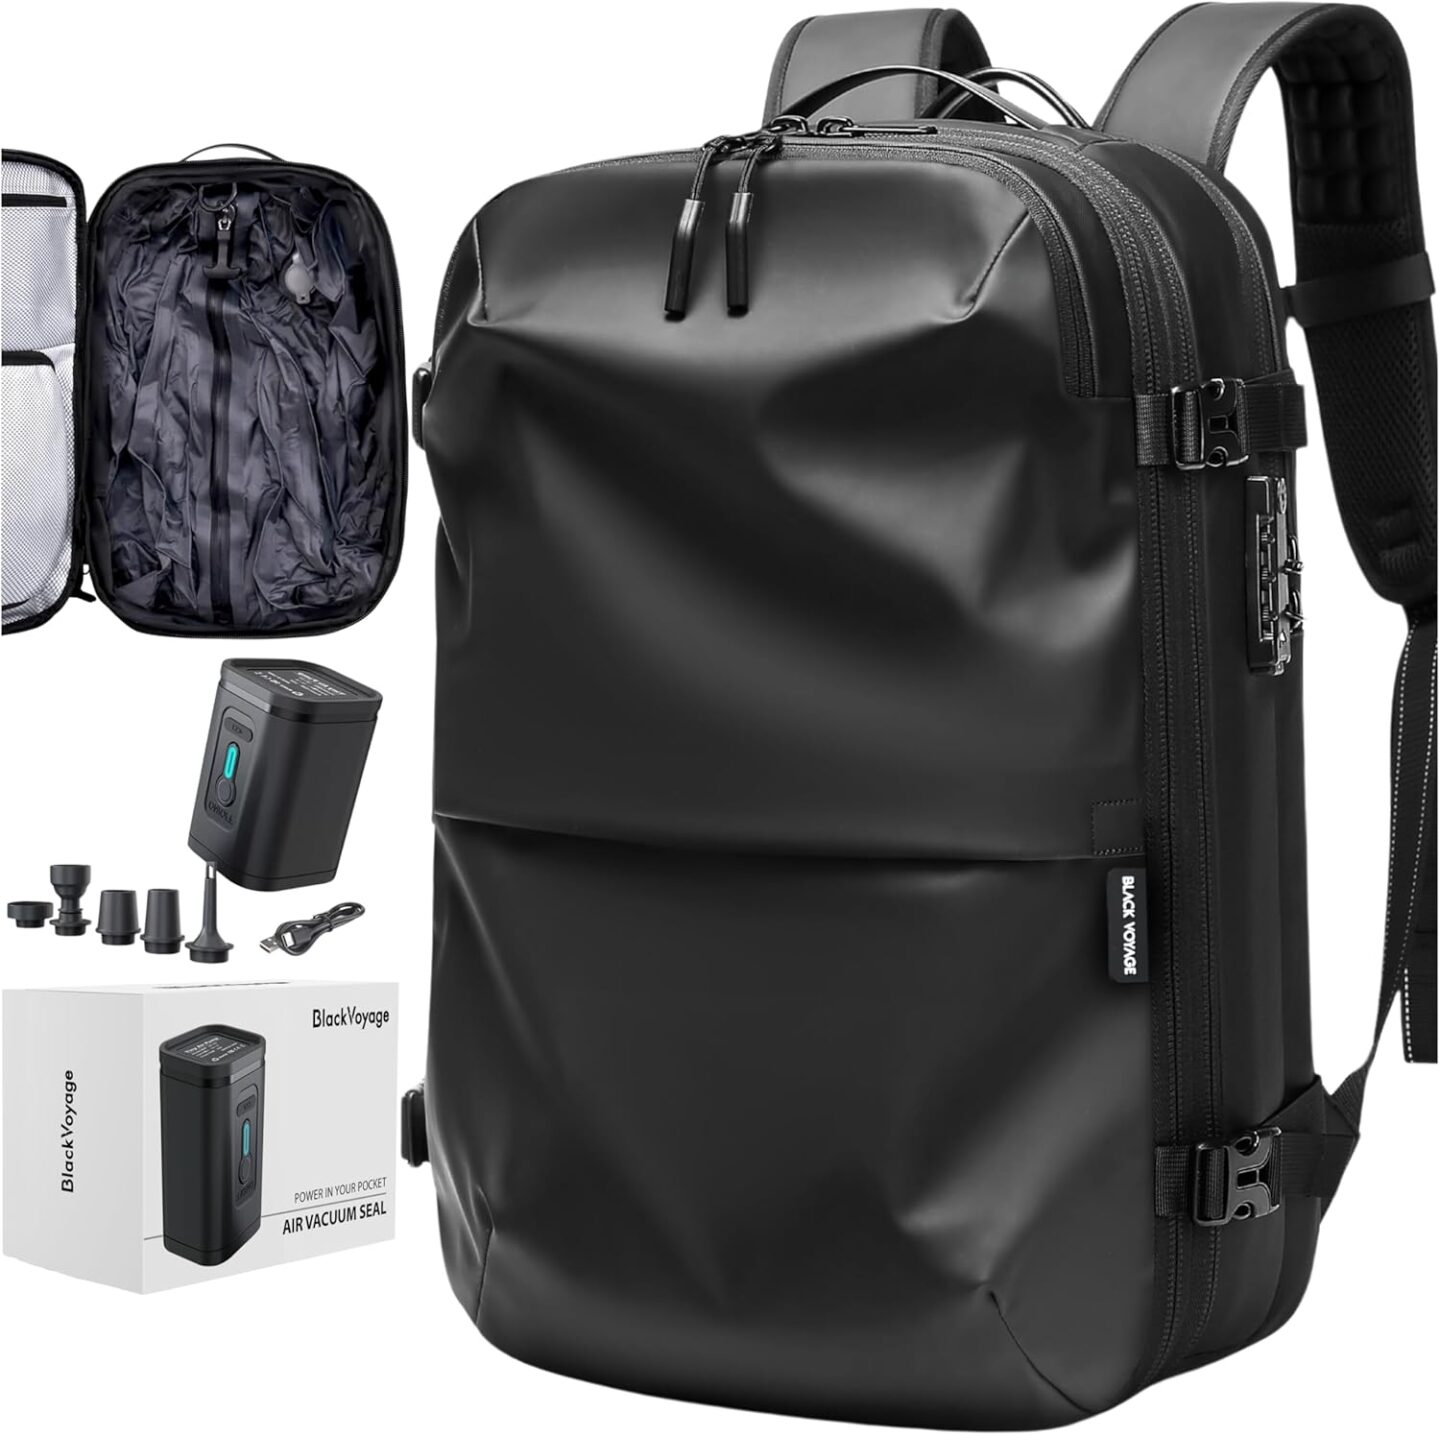

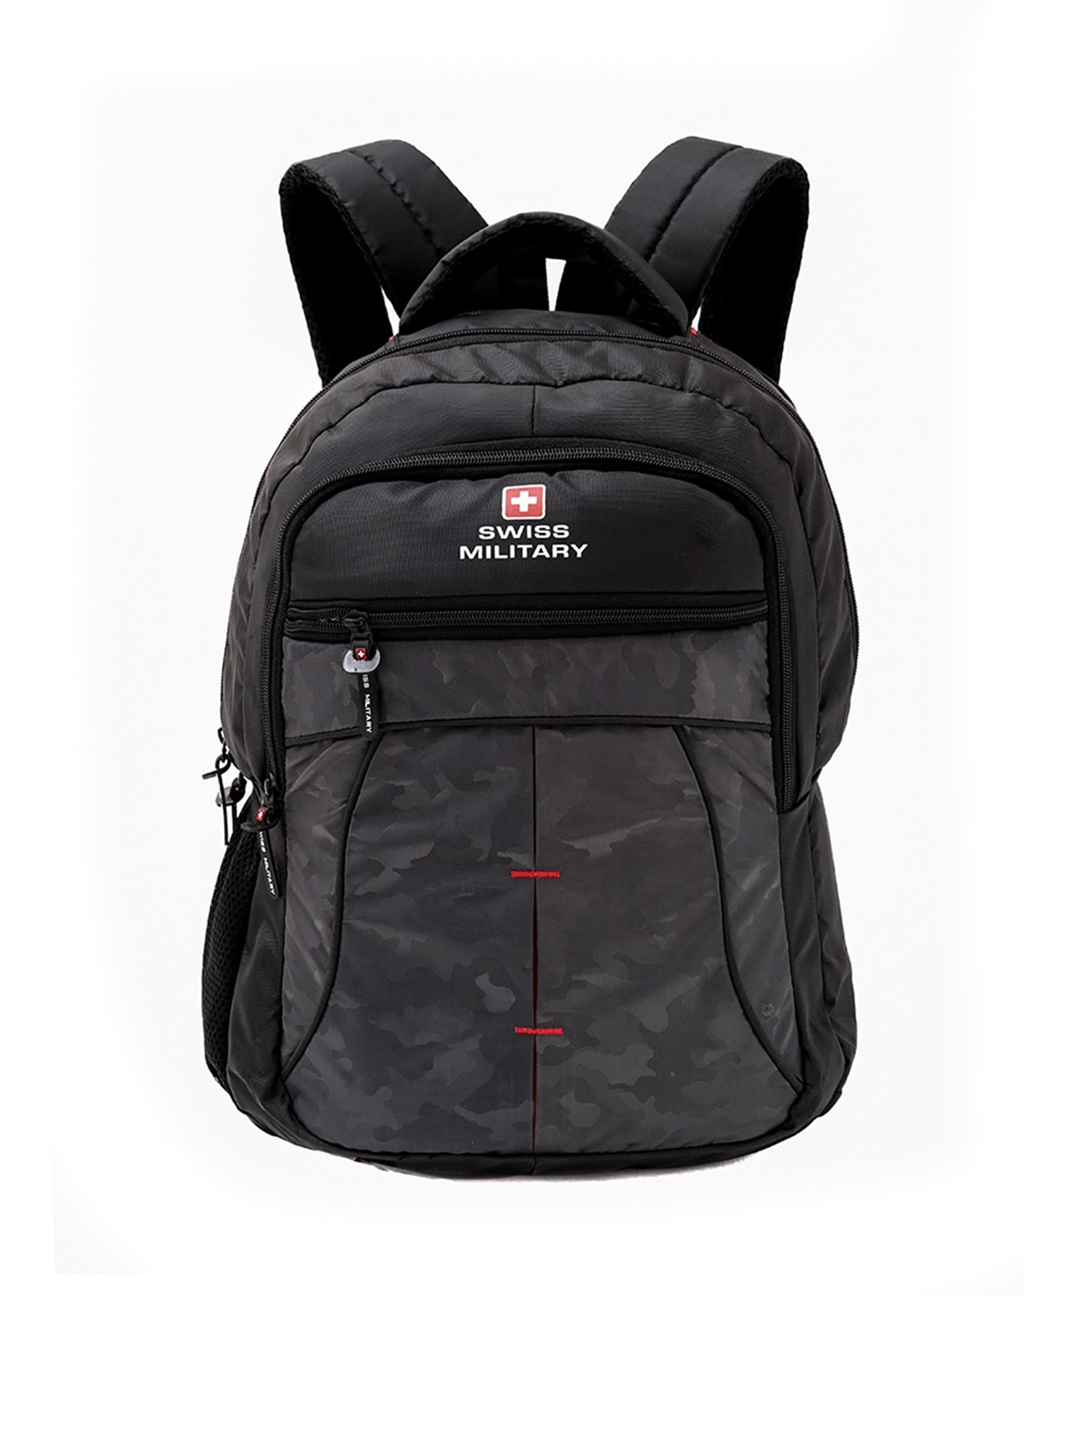

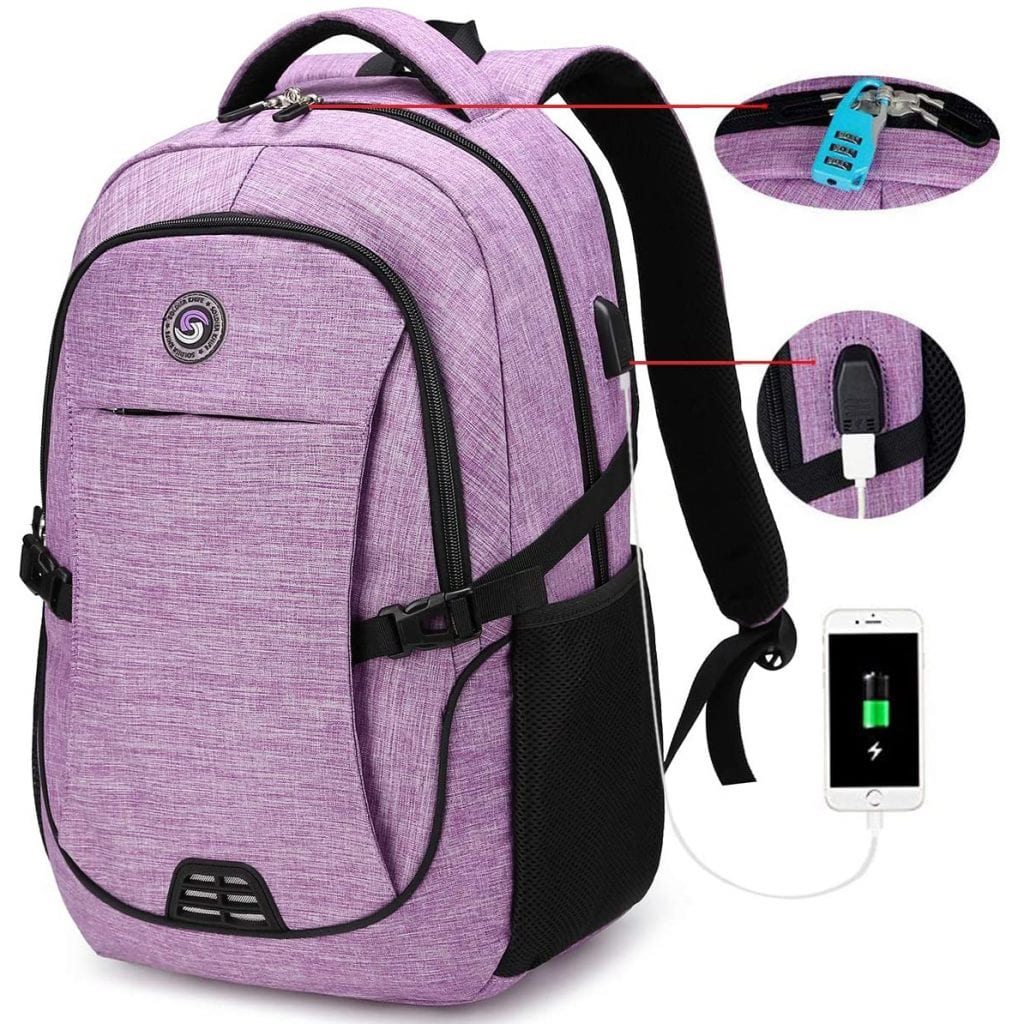


➡️ Novas sugestões encontradas na web:


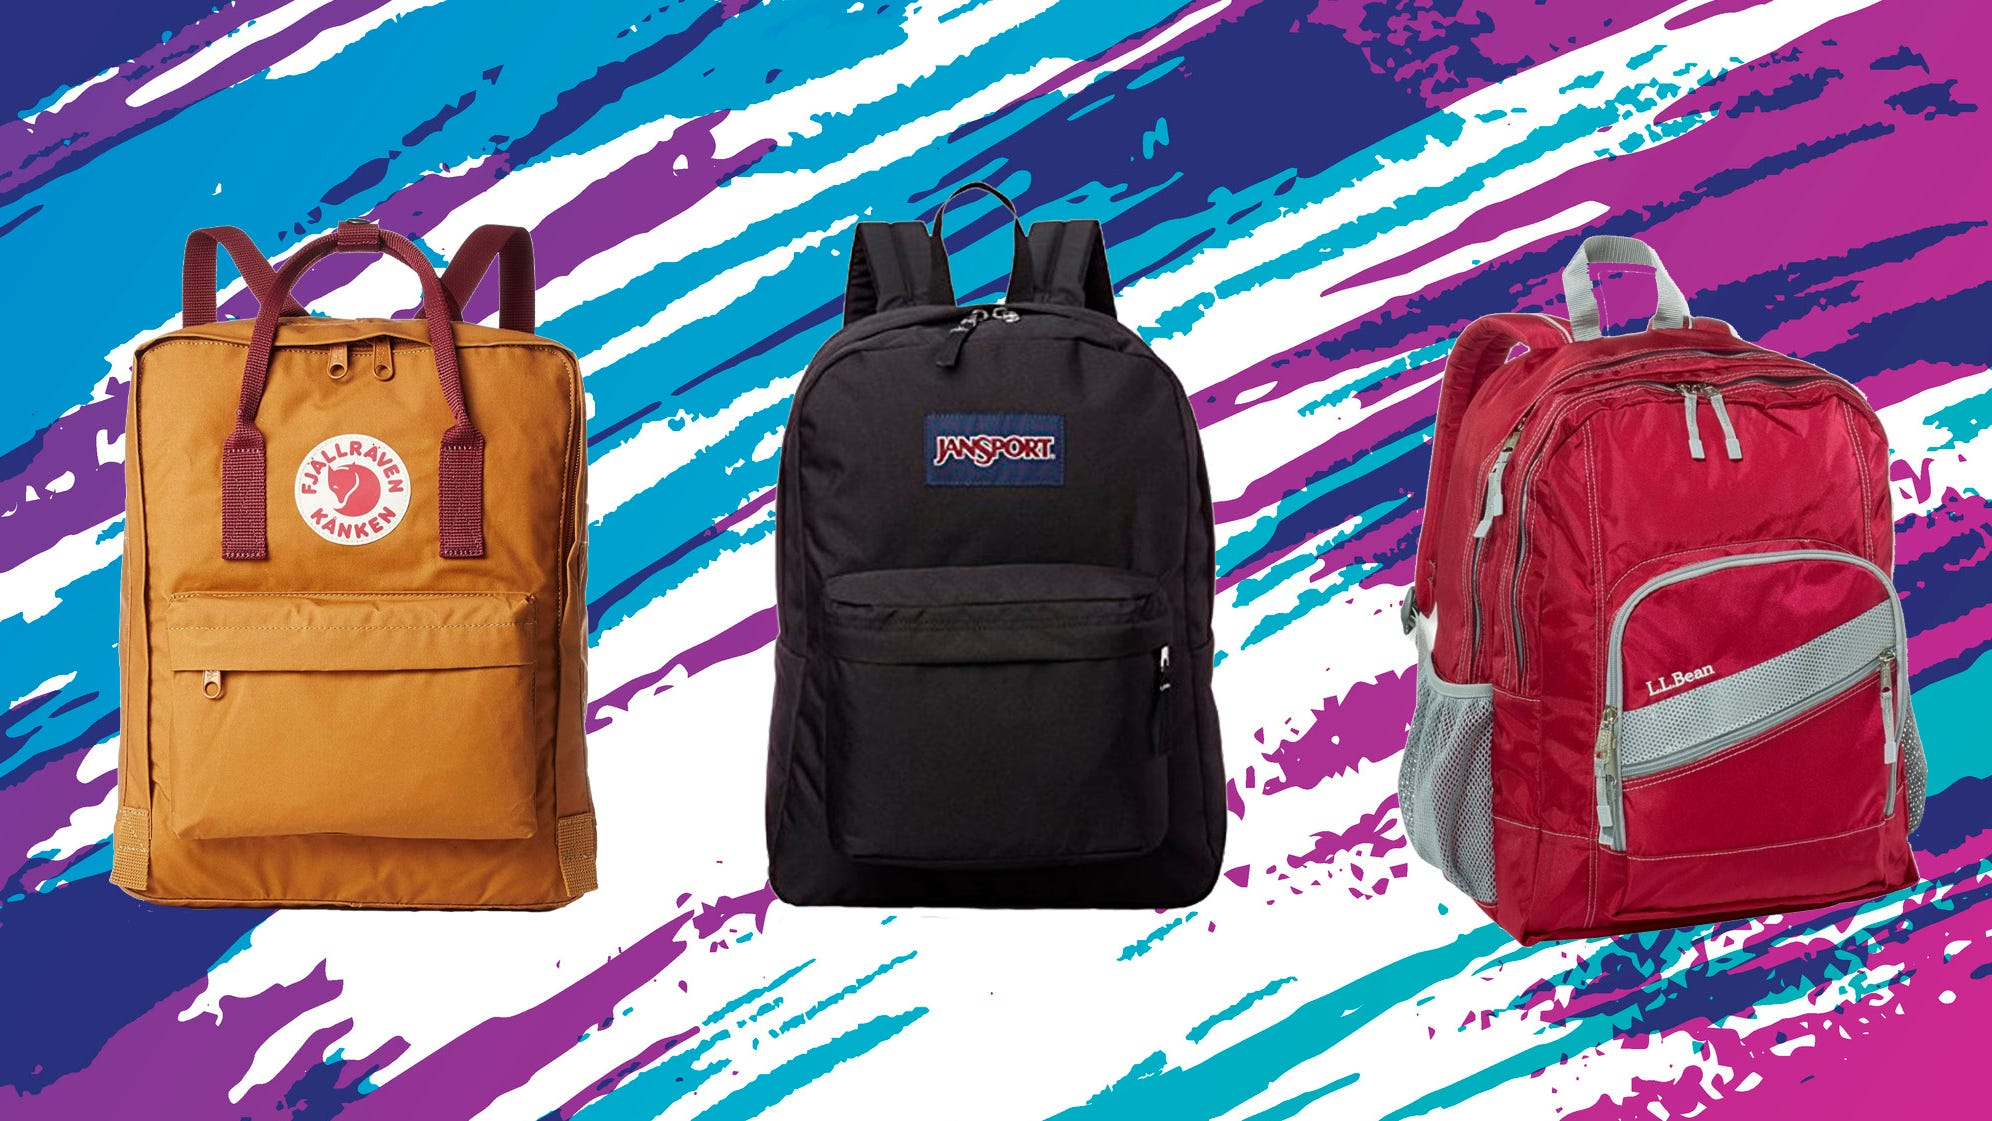

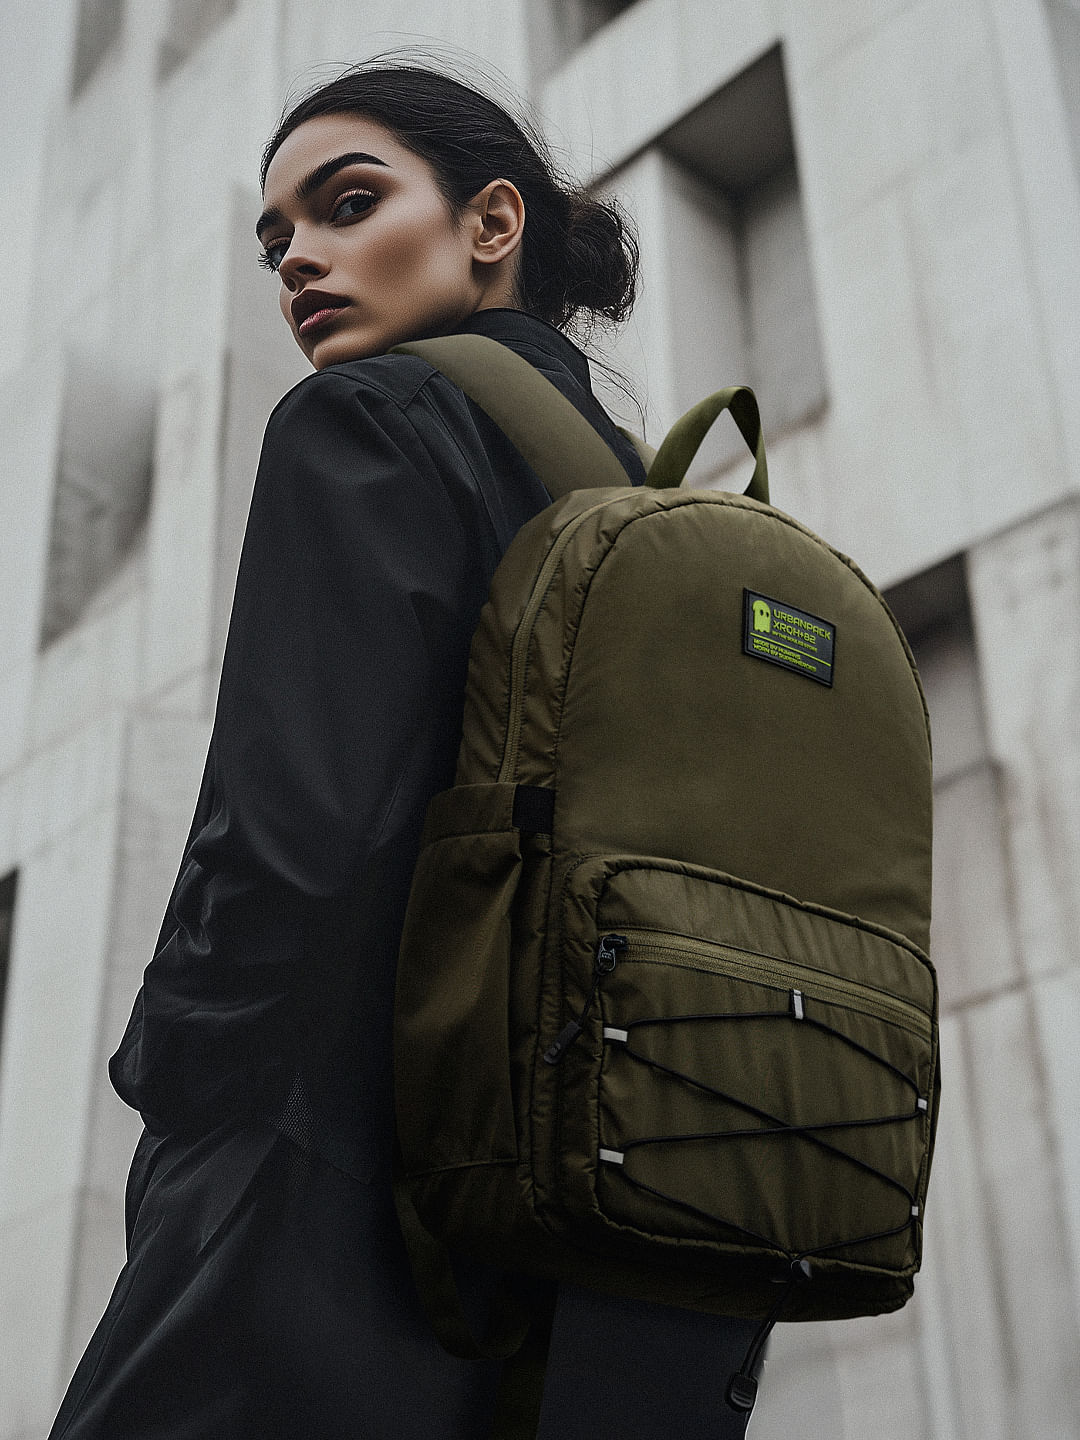

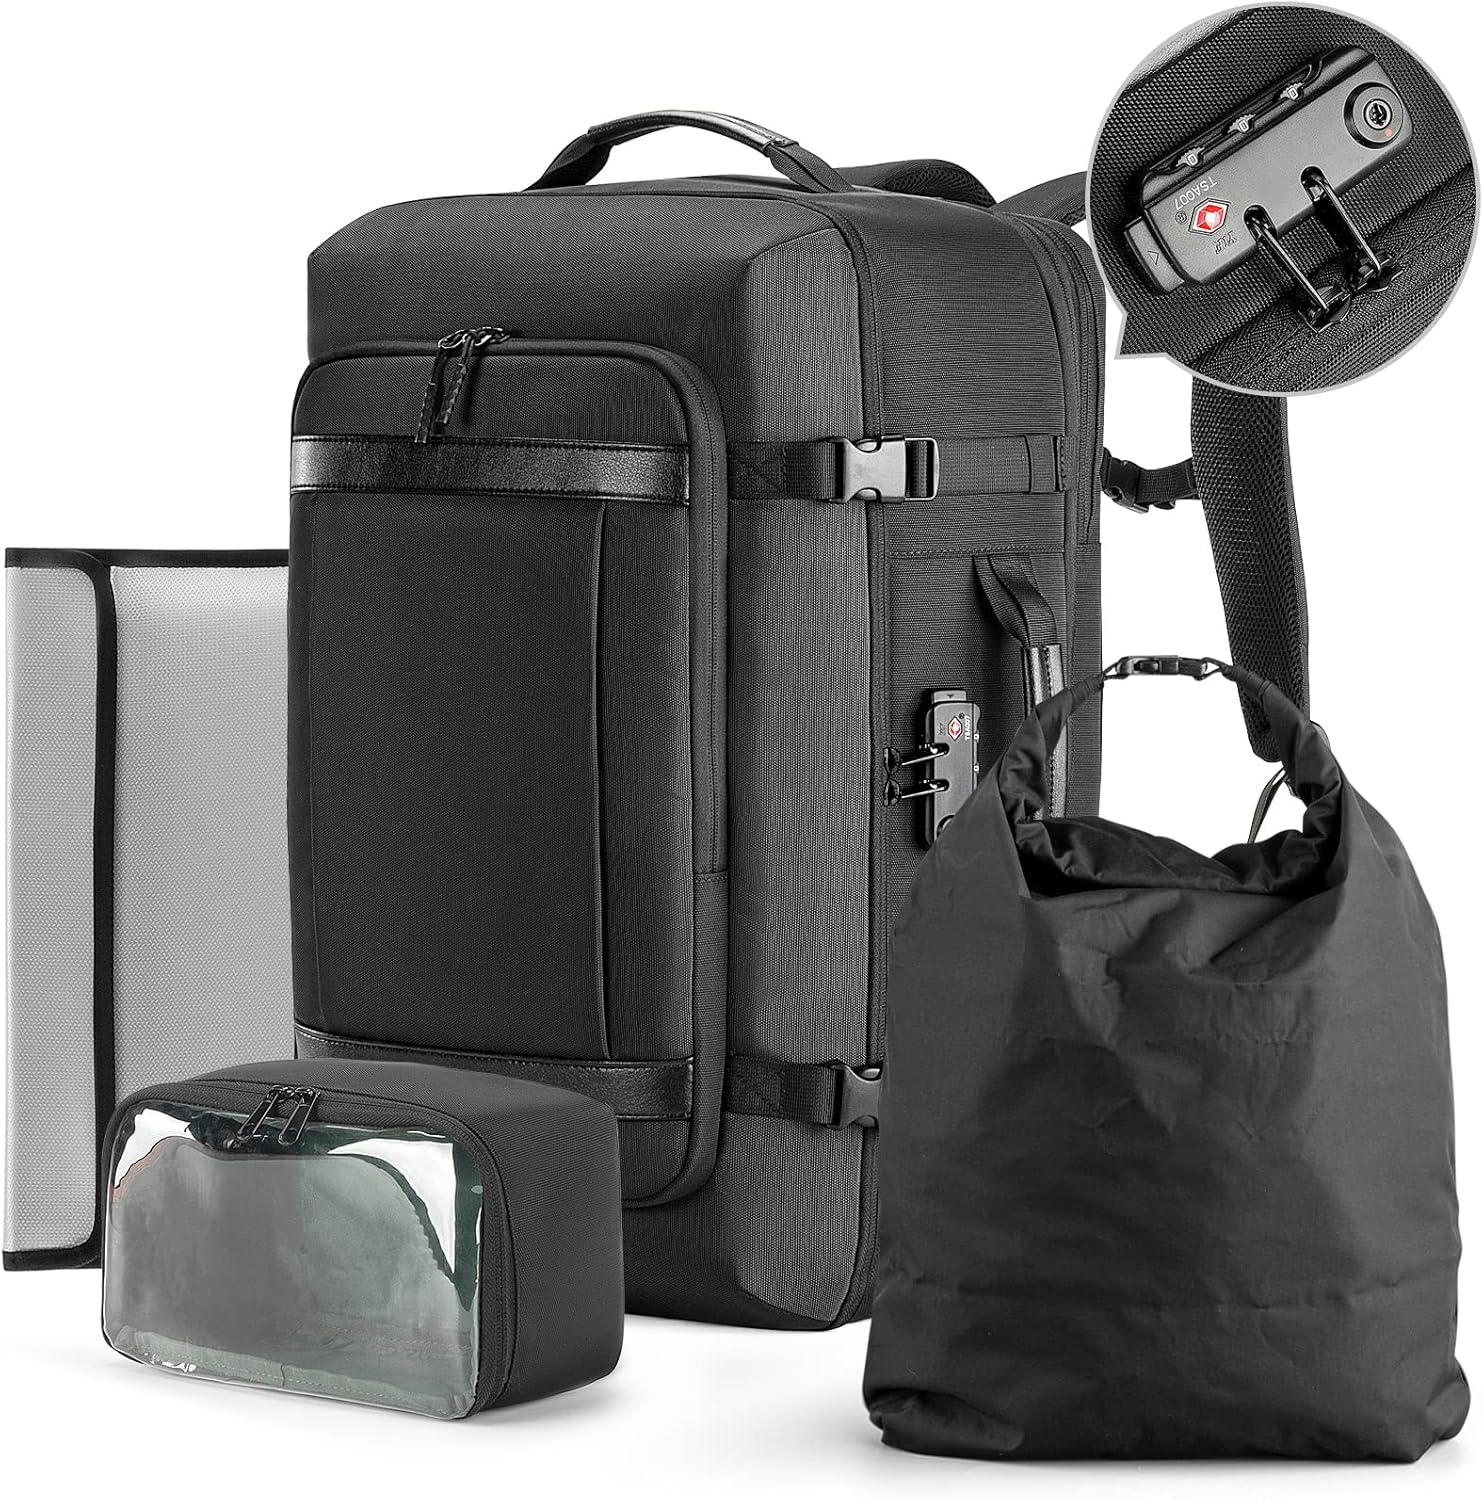

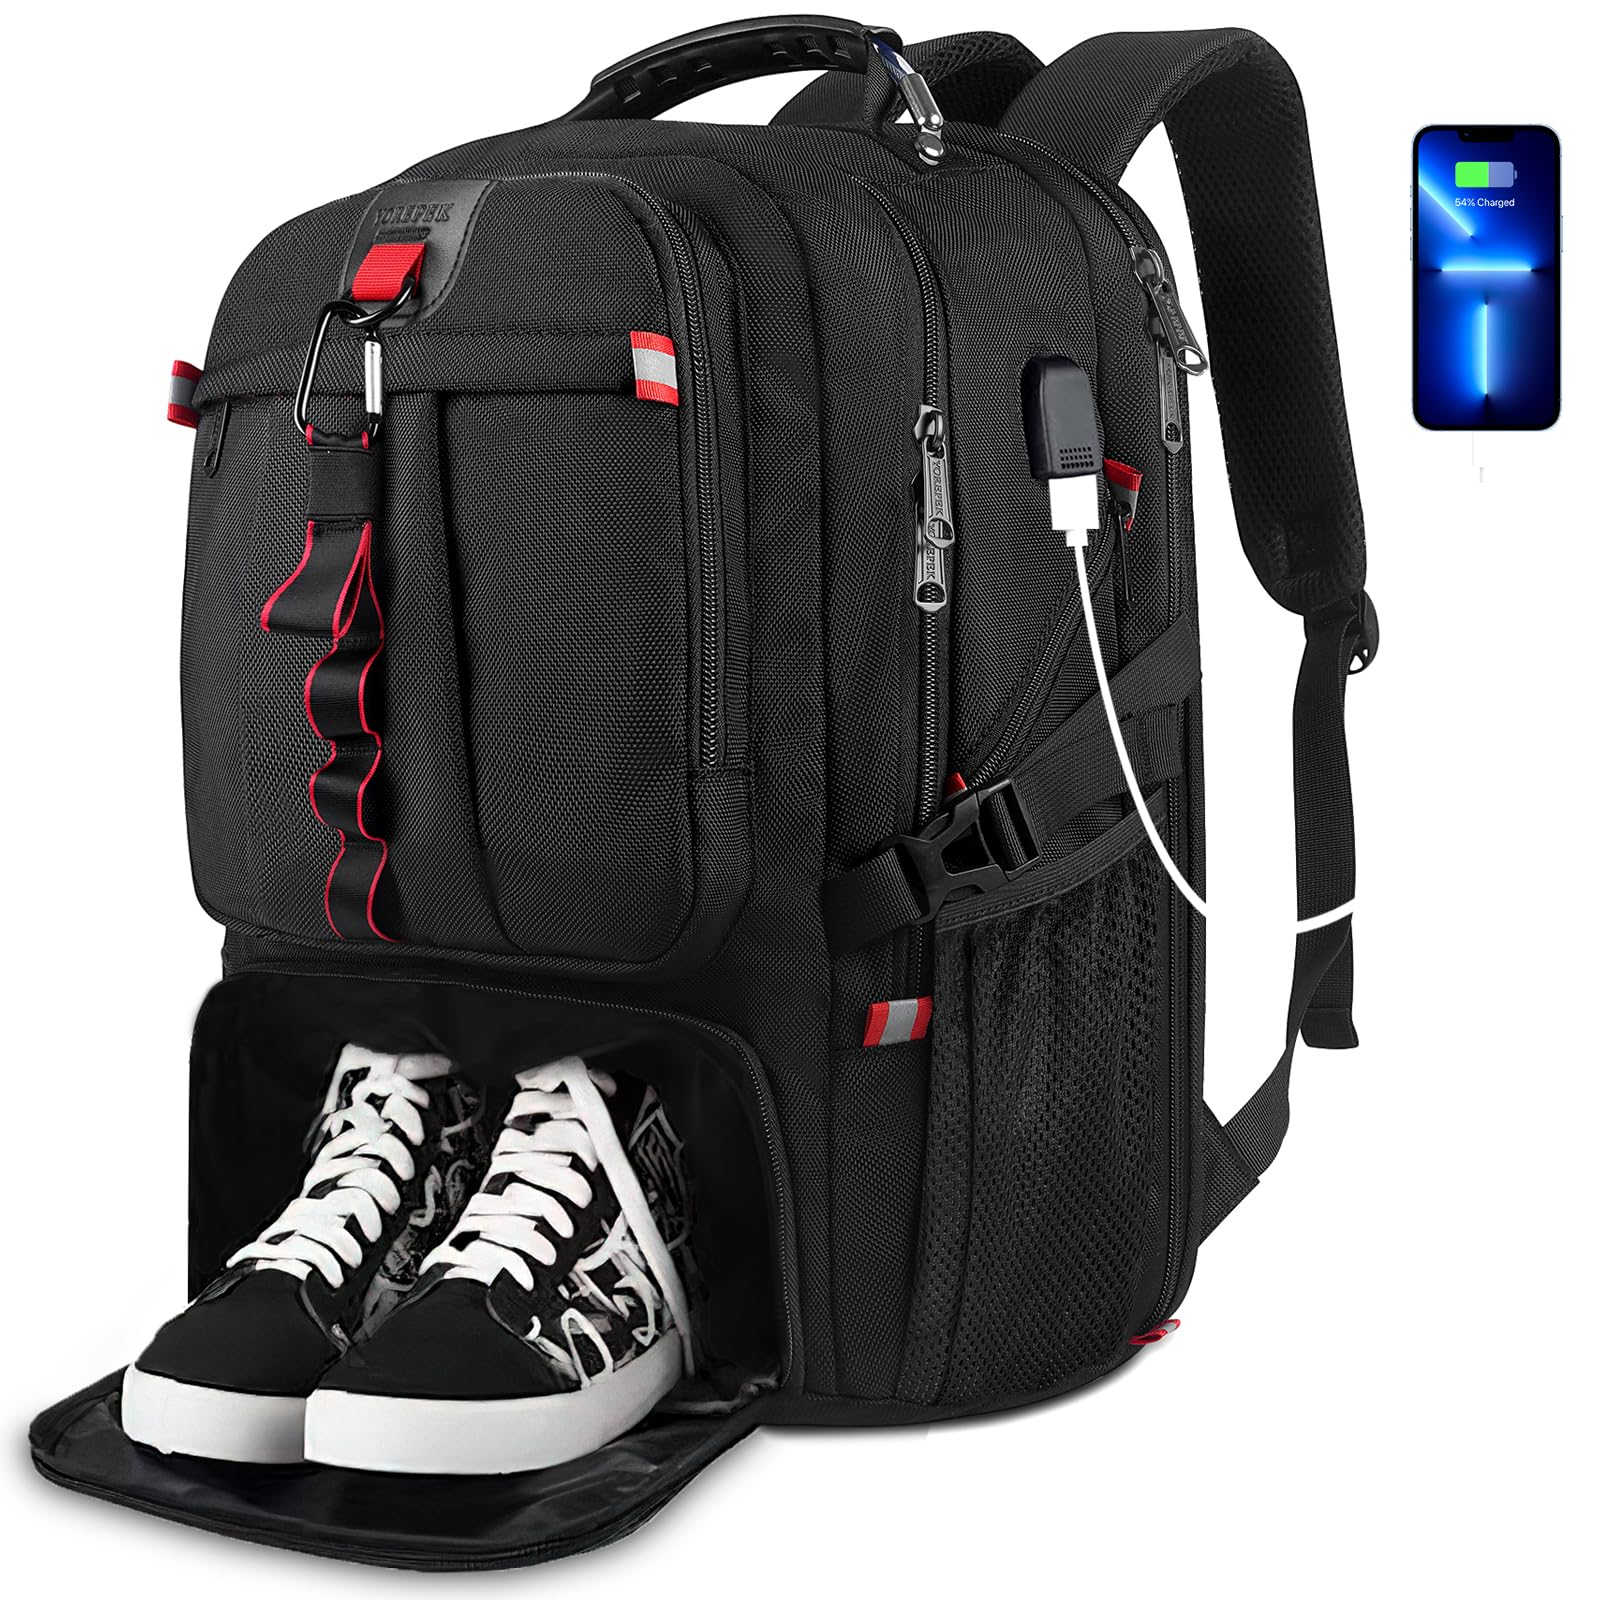

In [8]:
from google.colab import files
from IPython.display import display, Image as IPImage
import requests
from io import BytesIO

print("Faça o upload de uma imagem de teste (sneaker, watch, backpack ou laptop):")
uploaded = files.upload()

if uploaded:
    test_image_path = list(uploaded.keys())[0]

    print("\nImagem enviada:")
    display(IPImage(test_image_path, width=224))

    # ATUALIZADO: para receber os 3 resultados da função
    pred_class, similar_imgs, online_imgs = get_recommendations_complete(test_image_path)

    print("\n" + "="*50)
    print(f"✅ Objeto classificado como: {pred_class.upper()}")
    print("="*50)

    print("\n➡️ Imagens similares encontradas na nossa base de dados (da mesma classe):")
    if similar_imgs:
        for path in similar_imgs:
            display(IPImage(path, width=150))
    else:
        print("Nenhuma imagem similar encontrada.")

    # ADICIONADO DE VOLTA: Código para exibir as imagens da web
    print("\n➡️ Novas sugestões encontradas na web:")
    if online_imgs:
        for url in online_imgs:
            try:
                response = requests.get(url)
                display(IPImage(response.content, width=150))
            except:
                print(f"Não foi possível carregar: {url}")
    else:
        print("Nenhuma sugestão encontrada na web.")